GridWorld

In [31]:
import numpy as np
import matplotlib.pyplot as plt

In [32]:
class GridWorld:
    def __init__(self, stochastic=False, noise_prob=0.2):
        self.height = 4
        self.width = 4
        self.grid_size = (self.height, self.width)
        self.n_states = self.height * self.width
        self.n_actions = 4 # 0: up, 1: down, 2: left, 3: right
        self.stochastic = stochastic
        self.noise_prob = noise_prob
        self.goal_state = 15 # (3, 3)
        self.actions = {
            0: (-1, 0),
            1: (1, 0),
            2: (0, -1),
            3: (0, 1)
        }

    def coord_to_state(self, r, c):
        return r * self.width + c

    def state_to_coord(self, state):
        return divmod(state, self.width)

    def get_transitions(self, state, action):
        """Returns list of tuples: (probability, next_state, reward, is_terminal)"""
        if state == self.goal_state:
            return [(1.0, state, 0, True)]

        r, c = self.state_to_coord(state)

        def move(curr_r, curr_c, act):
            dr, dc = self.actions[act]
            nr, nc = max(0, min(self.height - 1, curr_r + dr)), max(0, min(self.width - 1, curr_c + dc))
            next_s = self.coord_to_state(nr, nc)
            reward = 10 if next_s == self.goal_state else -1
            return next_s, reward

        if not self.stochastic:
            next_s, reward = move(r, c, action)
            return [(1.0, next_s, reward, next_s == self.goal_state)]

        # if stochastic
        intended_ns, intended_reward = move(r, c, action)
        transitions = [(1.0 - self.noise_prob, intended_ns, intended_reward, intended_ns == self.goal_state)]
        other_actions = [a for a in range(4) if a != action]
        for alt_act in other_actions:
            next_s, reward = move(r, c, alt_act)
            transitions.append((self.noise_prob/3.0, next_s, reward, next_s == self.goal_state))

        return transitions

Policy Evaluation & Value Iteration

In [33]:
def policy_evaluation(env: GridWorld, policy, gamma=0.99, theta=1e-6):
    V = np.zeros(env.n_states)
    while True:
        delta = 0
        for s in range(env.n_states):
            v = V[s]
            new_v = 0
            for a in range(env.n_actions):
                prob_a = policy[s, a]
                for prob, next_s, reward, _ in env.get_transitions(s, a):
                    new_v += prob_a * prob * (reward + gamma * V[next_s])
            V[s] = new_v
            delta = max(delta, abs(v - V[s]))
        if delta < theta:
            break
    return V

In [34]:
def value_iteration(env: GridWorld, gamma=0.99, theta=1e-6):
    V = np.zeros(env.n_states)
    optimal_policy = np.zeros((env.n_states, env.n_actions))

    while True:
        delta = 0
        for s in range(env.n_states):
            if s == env.goal_state: continue
            v = V[s]
            q_values = []
            for a in range(env.n_actions):
                q_a = sum(prob * (reward + gamma * V[next_s]) for prob, next_s, reward, _ in env.get_transitions(s, a))
                q_values.append(q_a)
            V[s] = max(q_values)
            delta = max(delta, abs(v - V[s]))
        if delta < theta:
            break

    for s in range(env.n_states):
        q_values = [sum(prob * (reward + gamma * V[next_s]) for prob, next_s, reward, _ in env.get_transitions(s, a)) for a in range(env.n_actions)]
        optimal_policy[s, np.argmax(q_values)] = 1.0

    return V, optimal_policy

Model Free Control

In [35]:
def epsilon_greedy(Q, state, epsilon, n_actions):
    if np.random.rand() < epsilon:
        return np.random.choice(n_actions)
    return np.argmax(Q[state])

In [36]:
def sample_env(env: GridWorld, state, action):
    transitions = env.get_transitions(state, action)
    probs = [t[0] for t in transitions]
    idx = np.random.choice(len(transitions), p=probs)
    _, next_s, reward, done = transitions[idx]
    return next_s, reward, done

In [37]:
def q_learning(env: GridWorld, episodes=500, alpha=0.1, gamma=0.99, epsilon=0.1):
    """Off-policy TD control. Bootstraps off max_a Q(s', a), so it learns Q* regardless of
    how exploratory the behaviour policy is."""
    Q = np.zeros((env.n_states, env.n_actions))
    returns = []
    for ep in range(episodes):
        state = 0
        done = False
        ep_return = 0.0
        while not done:
            action = epsilon_greedy(Q, state, epsilon, env.n_actions)
            next_state, reward, done = sample_env(env, state, action)
            Q[state, action] += alpha * (reward + gamma * np.max(Q[next_state]) - Q[state, action])
            state = next_state
            ep_return += reward
        returns.append(ep_return)
    return Q, returns

In [38]:
def sarsa(env: GridWorld, episodes=500, alpha=0.1, gamma=0.99, epsilon=0.1):
    """On-policy TD control. Bootstraps off the action actually taken next, so it learns the
    value of the eps-greedy policy it follows -- not Q*."""
    Q = np.zeros((env.n_states, env.n_actions))
    returns = []
    for ep in range(episodes):
        state = 0
        action = epsilon_greedy(Q, state, epsilon, env.n_actions)
        done = False
        ep_return = 0.0
        while not done:
            next_state, reward, done = sample_env(env, state, action)
            next_action = epsilon_greedy(Q, next_state, epsilon, env.n_actions)
            Q[state, action] += alpha * (reward + gamma * Q[next_state, next_action] - Q[state, action])
            state = next_state
            action = next_action
            ep_return += reward
        returns.append(ep_return)
    return Q, returns

Rendering Helpers

In [39]:
ARROWS = {0: "^", 1: "v", 2: "<", 3: ">"}


def render_values(env: GridWorld, V, title):
    print(title)
    for r in range(env.height):
        print("   " + " ".join(f"{V[env.coord_to_state(r, c)]:7.2f}" for c in range(env.width)))


def render_policy(env: GridWorld, policy, title):
    print(title)
    for r in range(env.height):
        print("   " + "  ".join(
            "G" if env.coord_to_state(r, c) == env.goal_state
            else ARROWS[int(np.argmax(policy[env.coord_to_state(r, c)]))]
            for c in range(env.width)))


def greedy_policy_from_Q(Q):
    """One-hot policy matrix from an action-value table, same shape value_iteration returns"""
    policy = np.zeros_like(Q)
    policy[np.arange(len(Q)), Q.argmax(axis=1)] = 1.0
    return policy

Running the DP Methods

In [40]:
GAMMA, EPISODES = 0.99, 15000
ENVS = [("deterministic", GridWorld()), ("stochastic p=0.2", GridWorld(stochastic=True))]

V_opt, pi_opt = {}, {}
for name, env in ENVS:
    uniform = np.ones((env.n_states, env.n_actions)) / env.n_actions
    V_rand = policy_evaluation(env, uniform, gamma=GAMMA)
    V_opt[name], pi_opt[name] = value_iteration(env, gamma=GAMMA)

    render_values(env, V_opt[name], f"V* -- {name}")
    render_policy(env, pi_opt[name], "pi*")
    print(f"   V(start): random {V_rand[0]:.2f} -> optimal {V_opt[name][0]:.2f}\n")

V* -- deterministic
      4.61    5.67    6.73    7.81
      5.67    6.73    7.81    8.90
      6.73    7.81    8.90   10.00
      7.81    8.90   10.00    0.00
pi*
   v  v  v  v
   v  v  v  v
   v  v  v  v
   >  >  >  G
   V(start): random -32.68 -> optimal 4.61

V* -- stochastic p=0.2
      2.69    3.88    5.19    6.43
      3.88    5.11    6.53    7.88
      5.19    6.53    7.99    9.47
      6.43    7.88    9.47    0.00
pi*
   v  >  v  v
   v  v  v  v
   >  >  v  v
   >  >  >  G
   V(start): random -32.68 -> optimal 2.69



Model-Free Control -- Q-Learning vs SARSA

In [41]:
LEARNERS = [("q_learning", q_learning), ("sarsa", sarsa)]
histories = {}

for name, env in ENVS:
    for label, algo in LEARNERS:
        np.random.seed(0)
        Q, histories[name, label] = algo(env, episodes=EPISODES, alpha=0.1, gamma=GAMMA, epsilon=0.1)

        # score the learned policy with the exact evaluator, not a sampled rollout
        greedy = greedy_policy_from_Q(Q)
        V_greedy = policy_evaluation(env, greedy, gamma=GAMMA)
        render_policy(env, greedy, f"{label} -- {name}")
        print(f"   V(start) {V_greedy[0]:.2f} vs optimal {V_opt[name][0]:.2f}"
              f"   shortfall {V_opt[name][0] - V_greedy[0]:.4f}\n")

q_learning -- deterministic
   v  v  v  v
   >  >  v  v
   >  >  >  v
   >  >  >  G
   V(start) 4.61 vs optimal 4.61   shortfall 0.0000

sarsa -- deterministic
   v  v  v  v
   >  >  v  v
   >  >  v  v
   >  >  >  G
   V(start) 4.61 vs optimal 4.61   shortfall 0.0000

q_learning -- stochastic p=0.2
   >  v  >  v
   v  v  >  v
   >  >  >  v
   >  >  >  G
   V(start) 2.60 vs optimal 2.69   shortfall 0.0853

sarsa -- stochastic p=0.2
   v  v  >  v
   v  >  v  v
   v  v  >  v
   >  >  >  G
   V(start) 2.59 vs optimal 2.69   shortfall 0.0954



Learning Curves

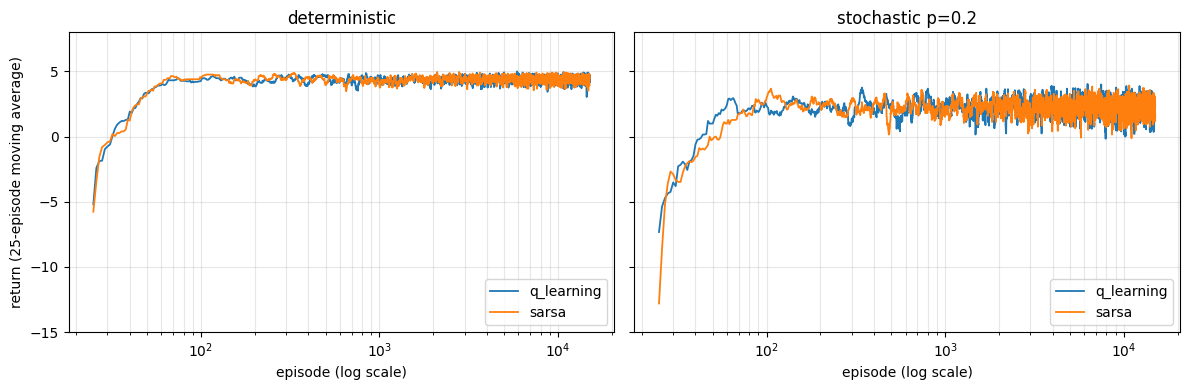

In [42]:
W = 25

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (name, _) in zip(axes, ENVS):
    for label, _ in LEARNERS:
        y = np.convolve(histories[name, label], np.ones(W) / W, mode="valid")
        ax.plot(np.arange(len(y)) + W, y, lw=1.3, label=label)
    ax.set(xscale="log", ylim=(-15, 8), title=name, xlabel="episode (log scale)")
    ax.grid(alpha=0.3, which="both")
    ax.legend(loc="lower right")
axes[0].set_ylabel(f"return ({W}-episode moving average)")
plt.tight_layout()
plt.show()

Findings

- Both envs share one $V^\pi$ under a uniform-random policy, since $\tfrac{1}{4}(0.8) + \tfrac{3}{4}\!\left(\tfrac{0.2}{3}\right) = 0.25$ per direction. Noise only bites once $\pi$ has preferences.
- The stochastic shortfall is the constant $\alpha = 0.1$, not the algorithm — $\alpha_t = N(s,a)^{-0.7}$ closes it.
- Q-learning and SARSA need a state where exploring is costly before $Q^*$ and $Q^{\pi_\epsilon}$ diverge. Cliff-world next.